# Dimensionless_Polymarket_CryptoBot_v1_Python

# Polymarket API Python

Resources:
- Polymarket API Docs
- Gamma API (Market Data)
- Data API (User Data)
- py-clob-client (3rd Party using Official SDK)
- NumPy / Matplotlib / Seaborn (Analytics & Charting)   

## 1. Setup   


In [1]:
%pip install -q py-clob-client-v2 requests numpy matplotlib seaborn
import sys
print(sys.executable)

Note: you may need to restart the kernel to use updated packages.
/usr/local/python/3.14.2/bin/python


In [2]:
import requests
import time
import json
import os
from pprint import pprint
from datetime import datetime, timezone
from collections import deque
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from py_clob_client_v2 import (
    ClobClient,
    OrderArgs,
    MarketOrderArgs,
    OrderType,
    PartialCreateOrderOptions,
    OpenOrderParams,
    BalanceAllowanceParams,
    AssetType,
    Side,
)

GAMMA_API = "https://gamma-api.polymarket.com"
DATA_API = "https://data-api.polymarket.com"
CLOB_API = "https://clob.polymarket.com"
CHAIN_ID = 137

# Analysis output directory
ANALYSIS_DIR = Path("analysis")
ANALYSIS_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Market Discovery   

In [3]:
# Fetch active markets sorted by volume
response = requests.get(
    f"{GAMMA_API}/markets",
    params={
        "limit": 80,
        "active": True,
        "closed": False,
        "order": "volume24hr",
        "ascending": False
    }
)
markets = response.json()
print(f"Found {len(markets)} markets")   

Found 80 markets


In [4]:
for m in markets[:6]:
    print(f"Question: {m['question']}")
    print(f"  Volume 24h: ${m.get('volume24hr', 0):,.0f}")
    print(f"  Liquidity: ${m.get('liquidityNum', 0):,.0f}")
    print(f"  Prices: {m.get('outcomePrices', 'N/A')}")
    print()   

Question: Dota 2: GamerLegion vs 1win - Game 2 Winner
  Volume 24h: $901,694
  Liquidity: $36,298
  Prices: ["0.275", "0.725"]

Question: Korea Open: Katie Volynets vs Kimberly Birrell
  Volume 24h: $617,667
  Liquidity: $7,552
  Prices: ["0.335", "0.665"]

Question: Will Mitch Landrieu win the 2028 Democratic presidential nomination?
  Volume 24h: $567,076
  Liquidity: $922,327
  Prices: ["0.0015", "0.9985"]

Question: Will Brazil win on 2026-09-25?
  Volume 24h: $542,959
  Liquidity: $431,341
  Prices: ["0.0005", "0.9995"]

Question: Will Shakhtar Donetsk win the 2026-27 UEFA Champions League Championship?
  Volume 24h: $426,283
  Liquidity: $437,082
  Prices: ["0.0015", "0.9985"]

Question: Strait of Hormuz traffic returns to normal by September 30?
  Volume 24h: $418,965
  Liquidity: $547,163
  Prices: ["0.003", "0.997"]



### 2a. Analytics: Volume & Liquidity Distribution   

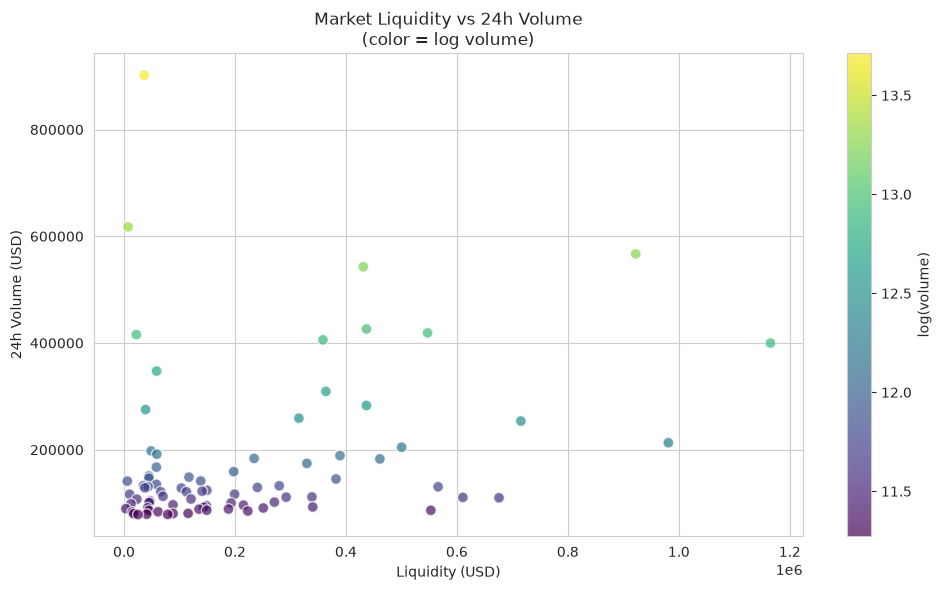

Saved: analysis/volume_liquidity_scatter.png


In [5]:
# Chart: Volume vs Liquidity scatter for discovered markets
vols = np.array([float(m.get("volume24hr", 0) or 0) for m in markets])
liqs = np.array([float(m.get("liquidityNum", 0) or 0) for m in markets])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(liqs, vols, c=np.log1p(vols), cmap="viridis", alpha=0.7, edgecolors="white", s=60)
ax.set_xlabel("Liquidity (USD)")
ax.set_ylabel("24h Volume (USD)")
ax.set_title("Market Liquidity vs 24h Volume\n(color = log volume)")
plt.colorbar(scatter, ax=ax, label="log(volume)")
plt.tight_layout()
out = ANALYSIS_DIR / "volume_liquidity_scatter.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out}")   

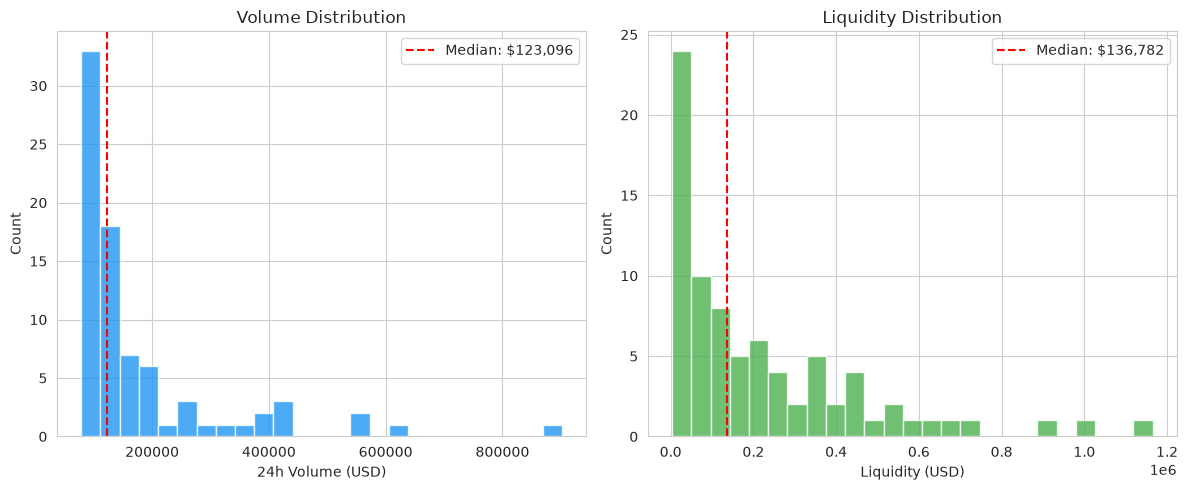

Saved: analysis/volume_liquidity_hist.png


In [6]:
# Chart: Volume histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(vols, bins=25, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(np.median(vols), color="red", linestyle="--", label=f"Median: ${np.median(vols):,.0f}")
axes[0].set_xlabel("24h Volume (USD)")
axes[0].set_ylabel("Count")
axes[0].set_title("Volume Distribution")
axes[0].legend()

axes[1].hist(liqs, bins=25, color="#4CAF50", edgecolor="white", alpha=0.8)
axes[1].axvline(np.median(liqs), color="red", linestyle="--", label=f"Median: ${np.median(liqs):,.0f}")
axes[1].set_xlabel("Liquidity (USD)")
axes[1].set_ylabel("Count")
axes[1].set_title("Liquidity Distribution")
axes[1].legend()

plt.tight_layout()
out = ANALYSIS_DIR / "volume_liquidity_hist.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out}")   

## 3. Market Deep Dive   

In [7]:
market = markets[2]
market   

{'id': '559704',
 'question': 'Will Mitch Landrieu win the 2028 Democratic presidential nomination?',
 'conditionId': '0xd0e58ada317f9778a221592cfed03405b235b137c8dd916817a39b72bf6dc19a',
 'slug': 'will-mitch-landrieu-win-the-2028-democratic-presidential-nomination',
 'resolutionSource': '',
 'endDate': '2028-11-07T00:00:00Z',
 'liquidity': '922327.15931',
 'startDate': '2025-07-11T18:36:48.657864Z',
 'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/will-mitch-landrieu-win-the-2028-democratic-presidential-nomination--ldVUPKxEwxr.jpg',
 'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/will-mitch-landrieu-win-the-2028-democratic-presidential-nomination--ldVUPKxEwxr.jpg',
 'description': 'This market will resolve to “Yes” if the named individual wins and accepts the 2028 nomination of the Democratic Party for U.S. president. Otherwise, this market will resolve to “No”.\n\nThe resolution source for this market will be a consensus of official Democratic Party sour

In [8]:
print(f"Market: {market['question']}")
print(f"End Date: {market['endDate']}")
print(f"Condition ID: {market['conditionId']}")   

Market: Will Mitch Landrieu win the 2028 Democratic presidential nomination?
End Date: 2028-11-07T00:00:00Z
Condition ID: 0xd0e58ada317f9778a221592cfed03405b235b137c8dd916817a39b72bf6dc19a


In [9]:
clob_token_ids = market.get('clobTokenIds')
clob_token_ids = json.loads(clob_token_ids)
print(f"Token IDs: {clob_token_ids}")

if len(clob_token_ids) >= 2:
    yes_token_id = clob_token_ids[0]
    no_token_id = clob_token_ids[1]
    print(f"YES token: {yes_token_id}")
    print(f"NO token: {no_token_id}")   

Token IDs: ['4865811310965824253043301476456494687696227904538198271117692275943047535567', '79794608519930936057256245365460158683416637197135162121080424897667989834195']
YES token: 4865811310965824253043301476456494687696227904538198271117692275943047535567
NO token: 79794608519930936057256245365460158683416637197135162121080424897667989834195


## 4. Order Book Analysis   

In [10]:
# Read-only client for order book
client = ClobClient(host=CLOB_API, chain_id=CHAIN_ID)   

In [11]:
# Fetch order book for YES token
book = client.get_order_book(yes_token_id)

sorted_bids = sorted(book["bids"], key=lambda x: float(x["price"]), reverse=True)
sorted_asks = sorted(book["asks"], key=lambda x: float(x["price"]), reverse=False)

print("=== YES Token Order Book ===")
print(f"\nTop 5 Asks (sell orders):")
for ask in sorted_asks[:5]:
    print(f"  Price: {ask['price']} | Size: {ask['size']}")

print(f"\nTop 5 Bids (buy orders):")
for bid in sorted_bids[:5]:
    print(f"  Price: {bid['price']} | Size: {bid['size']}")   

=== YES Token Order Book ===

Top 5 Asks (sell orders):
  Price: 0.002 | Size: 296022.35
  Price: 0.01 | Size: 581576.04
  Price: 0.02 | Size: 13713.5
  Price: 0.151 | Size: 40
  Price: 0.152 | Size: 12.8

Top 5 Bids (buy orders):
  Price: 0.001 | Size: 435157.51


In [12]:
# Get midpoint, prices, and spread
mid = client.get_midpoint(yes_token_id)
buy_price = client.get_price(yes_token_id, side="BUY")
sell_price = client.get_price(yes_token_id, side="SELL")
spread = client.get_spread(yes_token_id)

print(f"Midpoint: {mid['mid']}")
print(f"Best ask (buy at): {buy_price['price']}")
print(f"Best bid (sell at): {sell_price['price']}")
print(f"Spread: {spread['spread']}")   

Midpoint: 0.0015
Best ask (buy at): 0.001
Best bid (sell at): 0.002
Spread: 0.001


### 4a. Analytics: Order Book Depth Chart   

In [13]:
# Parse bids/asks into numeric arrays
bids = [(float(b["price"]), float(b["size"])) for b in book.get("bids", [])]
asks = [(float(a["price"]), float(a["size"])) for a in book.get("asks", [])]

best_bid = max(p for p, _ in bids) if bids else 0
best_ask = min(p for p, _ in asks) if asks else 1
midpoint = (best_bid + best_ask) / 2.0
spread_abs = best_ask - best_bid
spread_rel = spread_abs / midpoint if midpoint > 0 else 1.0

print(f"Best Bid: {best_bid:.4f}")
print(f"Best Ask: {best_ask:.4f}")
print(f"Midpoint: {midpoint:.4f}")
print(f"Spread (abs): {spread_abs:.4f}")
print(f"Spread (rel): {spread_rel:.4f}")   

Best Bid: 0.0010
Best Ask: 0.0020
Midpoint: 0.0015
Spread (abs): 0.0010
Spread (rel): 0.6667


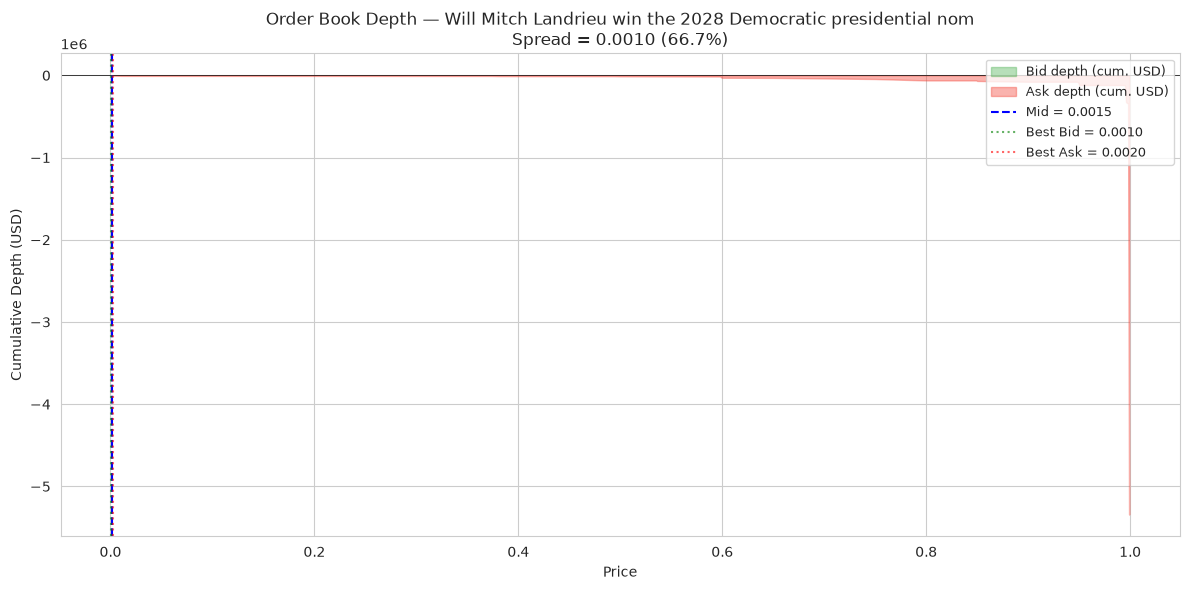

Saved: analysis/order_book_depth.png


In [14]:
# Chart: Order book depth (cumulative USD)
bids_sorted = sorted(bids, key=lambda x: x[0])
asks_sorted = sorted(asks, key=lambda x: x[0])

bid_prices = [p for p, _ in bids_sorted]
ask_prices = [p for p, _ in asks_sorted]
bid_cum = np.cumsum([p * s for p, s in bids_sorted])
ask_cum = np.cumsum([p * s for p, s in asks_sorted])

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(bid_prices, bid_cum, alpha=0.4, color="#4CAF50", label="Bid depth (cum. USD)")
ax.fill_between(ask_prices, -ask_cum, alpha=0.4, color="#F44336", label="Ask depth (cum. USD)")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(midpoint, color="blue", linestyle="--", label=f"Mid = {midpoint:.4f}")
ax.axvline(best_bid, color="green", linestyle=":", alpha=0.6, label=f"Best Bid = {best_bid:.4f}")
ax.axvline(best_ask, color="red", linestyle=":", alpha=0.6, label=f"Best Ask = {best_ask:.4f}")

ax.set_xlabel("Price")
ax.set_ylabel("Cumulative Depth (USD)")
ax.set_title(f"Order Book Depth — {market['question'][:60]}\n"
             f"Spread = {spread_abs:.4f} ({spread_rel:.1%})")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
out = ANALYSIS_DIR / "order_book_depth.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out}")   

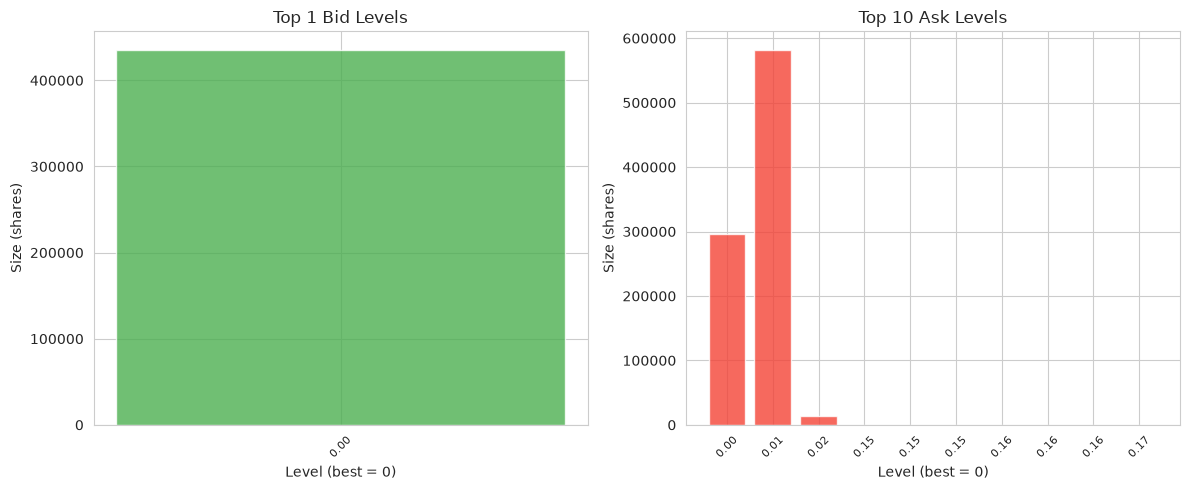

Saved: analysis/order_book_levels.png


In [15]:
# Chart: Bid/Ask size distribution (top N levels)
top_n = 10
top_bids = sorted(bids, key=lambda x: -x[0])[:top_n]
top_asks = sorted(asks, key=lambda x: x[0])[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(len(top_bids)), [s for _, s in top_bids],
            color="#4CAF50", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Level (best = 0)")
axes[0].set_ylabel("Size (shares)")
axes[0].set_title(f"Top {len(top_bids)} Bid Levels")
axes[0].set_xticks(range(len(top_bids)))
axes[0].set_xticklabels([f"{p:.2f}" for p, _ in top_bids], rotation=45, fontsize=8)

axes[1].bar(range(len(top_asks)), [s for _, s in top_asks],
            color="#F44336", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Level (best = 0)")
axes[1].set_ylabel("Size (shares)")
axes[1].set_title(f"Top {len(top_asks)} Ask Levels")
axes[1].set_xticks(range(len(top_asks)))
axes[1].set_xticklabels([f"{p:.2f}" for p, _ in top_asks], rotation=45, fontsize=8)

plt.tight_layout()
out = ANALYSIS_DIR / "order_book_levels.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out}")   

## 5. Authentication

In [16]:
# Your credentials (keep these secret!)
FUNDER_ADDRESS = "your-wallet-address"  # For proxy wallets
PRIVATE_KEY = "your-private-key-here"  # Never commit this

# Signature types:
# 0 = EOA (MetaMask, hardware wallet)
# 1 = Email/Magic wallet
# 2 = Browser wallet proxy
# 3 = POLY_1271 (deposit wallet - recommended for bots)
SIGNATURE_TYPE = 3   

In [17]:
# Initialize authenticated client
auth_client = ClobClient(
    host=CLOB_API,
    chain_id=CHAIN_ID,
    key=PRIVATE_KEY,
    signature_type=SIGNATURE_TYPE,
    funder=FUNDER_ADDRESS,
)

# Set API credentials
creds = auth_client.create_or_derive_api_key()
auth_client.set_api_creds(creds)   

Error: Non-hexadecimal digit found

In [ ]:
balance = auth_client.get_balance_allowance(BalanceAllowanceParams(asset_type=AssetType.COLLATERAL))
usd_balance = int(balance['balance']) / 1e6
print(f"Balance: ${usd_balance:.2f}")   

## 6. Place a Market Order   

In [ ]:
# Create a market order: Buy $1 worth of YES shares at market price
market_order = MarketOrderArgs(
    token_id=yes_token_id,
    amount=1.0,  # Dollar amount to spend
    side=Side.BUY,
    order_type=OrderType.FOK,
)

opts = PartialCreateOrderOptions(tick_size="0.01")

response = auth_client.create_and_post_market_order(
    order_args=market_order,
    options=opts,
    order_type=OrderType.FOK,
)
print("Market order executed!")
pprint(response)   

## 7. Place a Limit Order   

In [ ]:
# Create a limit order: Buy 10 YES shares at $0.50
limit_order = OrderArgs(
    token_id=yes_token_id,
    price=0.50,
    size=10.0,
    side=Side.BUY
)

opts = PartialCreateOrderOptions(tick_size="0.01")

response = auth_client.create_and_post_order(
    order_args=limit_order,
    options=opts,
    order_type=OrderType.GTC,
)
print(f"Order placed!")
pprint(response)   

## 8. Open Orders   

In [ ]:
# Get your open orders
open_orders = auth_client.get_open_orders(OpenOrderParams())
print(f"Open orders: {len(open_orders)}")

for order in open_orders[:5]:
    print(f"  ID: {order['id'][:20]}...")
    print(f"  Side: {order['side']} | Price: {order['price']} | Size: {order['original_size']}")
    print()   

### 8a. Analytics: Open Orders Summary   

In [ ]:
# Chart: Open orders by side and price
if open_orders:
    sides = [o.get("side", "").upper() for o in open_orders]
    prices = [float(o.get("price", 0)) for o in open_orders]
    sizes = [float(o.get("original_size", 0)) for o in open_orders]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#4CAF50" if s == "BUY" else "#F44336" for s in sides]
    ax.bar(range(len(open_orders)), sizes, color=colors, edgecolor="white", alpha=0.8)
    ax.set_xlabel("Order #")
    ax.set_ylabel("Size (shares)")
    ax.set_title(f"Open Orders ({len(open_orders)} total)")
    ax.set_xticks(range(len(open_orders)))
    ax.set_xticklabels([f"${p:.2f}" for p in prices], rotation=45, fontsize=8)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#4CAF50", label="BUY"),
                       Patch(facecolor="#F44336", label="SELL")]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    out = ANALYSIS_DIR / "open_orders.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out}")
else:
    print("No open orders to chart.")   

## 9. Cancel Orders   

In [ ]:
# Cancel a specific order
if open_orders:
    order_id = open_orders[0]["id"]
    result = auth_client.cancel_orders([order_id])
    print(f"Cancelled order: {order_id[:20]}...")
    pprint(result)   

In [ ]:
# Cancel all orders
result = auth_client.cancel_all()
print("All orders cancelled!")
pprint(result)   

## 10: Price Tracker & Contrarian Signal   

In [ ]:
# Rolling midpoint tracker with contrarian z-score signal

HISTORY_WINDOW = 60
MIN_HISTORY = 15
Z_THRESHOLD = 1.5

midpoint_history: deque = deque(maxlen=HISTORY_WINDOW)

def update_midpoint(token_id: str = yes_token_id) -> float | None:
    """Fetch current midpoint and append to history."""
    try:
        mid = client.get_midpoint(token_id)
        if isinstance(mid, dict):
            val = float(mid.get("mid", mid.get("midPrice", 0)))
        else:
            val = float(mid)
        midpoint_history.append(val)
        return val
    except Exception as e:
        print(f"Midpoint fetch error: {e}")
        return None

def compute_z_score() -> float | None:
    """Compute z-score of current price vs rolling history."""
    if len(midpoint_history) < MIN_HISTORY:
        return None
    arr = np.array(midpoint_history, dtype=np.float64)
    mean = arr.mean()
    std = arr.std(ddof=1)
    if std < 1e-6:
        return None
    return (arr[-1] - mean) / std

# Simulate: update 20 times (in production, run on a timer)
print("Collecting midpoint history…")
for i in range(20):
    val = update_midpoint()
    if val is not None:
        print(f"  [{i+1:2d}] mid = {val:.4f}")
    time.sleep(1)

z = compute_z_score()
print(f"\nZ-score: {z:.4f}" if z is not None else "\nZ-score: insufficient data")
if z is not None and abs(z) > Z_THRESHOLD:
    direction = "BUY NO (contrarian)" if z > 0 else "BUY YES (contrarian)"
    print(f"⚡ SIGNAL: {direction} (|z| = {abs(z):.2f} > {Z_THRESHOLD})")
else:
    print("No contrarian signal.")   

### 10a. Analytics: Midpoint History & Z-Score Chart   

In [ ]:
# Chart: Midpoint history with z-score bands
if len(midpoint_history) >= MIN_HISTORY:
    arr = np.array(midpoint_history, dtype=np.float64)
    mean = arr.mean()
    std = arr.std(ddof=1)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Top panel: price history
    axes[0].plot(arr, color="#3F51B5", linewidth=1.5, label="Midpoint")
    axes[0].axhline(mean, color="gray", linestyle=":", label=f"Mean = {mean:.4f}")
    axes[0].axhline(mean + Z_THRESHOLD * std, color="red", linestyle="--", alpha=0.6,
                    label=f"+{Z_THRESHOLD}σ")
    axes[0].axhline(mean - Z_THRESHOLD * std, color="red", linestyle="--", alpha=0.6,
                    label=f"-{Z_THRESHOLD}σ")
    axes[0].set_ylabel("Price")
    axes[0].set_title(f"Midpoint History — {market['question'][:50]}")
    axes[0].legend(fontsize=9)

    # Bottom panel: z-score over time
    z_scores = (arr - mean) / std
    colors = ["#F44336" if abs(z) > Z_THRESHOLD else "#9E9E9E" for z in z_scores]
    axes[1].bar(range(len(z_scores)), z_scores, color=colors, edgecolor="white", alpha=0.8)
    axes[1].axhline(Z_THRESHOLD, color="red", linestyle="--", alpha=0.5)
    axes[1].axhline(-Z_THRESHOLD, color="red", linestyle="--", alpha=0.5)
    axes[1].axhline(0, color="gray", linewidth=0.5)
    axes[1].set_xlabel("Sample")
    axes[1].set_ylabel("Z-Score")
    axes[1].set_title("Z-Score Over Time (red = beyond threshold)")

    plt.tight_layout()
    out = ANALYSIS_DIR / "midpoint_zscore.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out}")
else:
    print(f"Need at least {MIN_HISTORY} samples (have {len(midpoint_history)}).")   